# EDA: Online Retail Dataset

**Цель:** понять структуру данных, найти проблемы (пропуски, отмены, выбросы), 
определить, что нужно чистить перед построением рекомендательной системы.

**Датасет:** транзакции UK онлайн-магазина, 01.12.2010 – 09.12.2011.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

print("Библиотеки загружены")
print("pandas", pd.__version__)
print("numpy", np.__version__)

Библиотеки загружены
pandas 2.1.4
numpy 1.26.2


In [16]:
PATH = "../data/raw/data.csv"

df = pd.read_csv(PATH, encoding="ISO-8859-1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=False)

print("Загружено:", df.shape)
print("Тип InvoiceDate:", df["InvoiceDate"].dtype)
df.head()

Загружено: (541909, 8)
Тип InvoiceDate: datetime64[ns]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Наблюдения

- 541 909 строк, 8 колонок
- Данные — это построчные транзакции: один товар = одна строка
- Есть колонка `CustomerID` — значит, можем строить рекомендации
- Есть колонка `InvoiceDate` — можем упорядочить покупки по времени

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Проблемы, которые нужно решить

1. `InvoiceDate` — не datetime, нужно распарсить.
2. `CustomerID` — 135K пропусков (гостевые покупки), для рекомендаций бесполезны.
3. `Description` — 1.5K пропусков, заполним/удалим.
4. `Quantity` и `UnitPrice` — нужно проверить на отрицательные и нулевые значения.

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
(df.isnull().sum() / len(df) * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [6]:
print("Дубликатов:", df.duplicated().sum())

Дубликатов: 5268


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Что вижу в describe

- `Quantity` уходит в минус; возвраты/корректировки, удалим.
- `UnitPrice` тоже в минус; ошибки, удалим.
- `CustomerID` — корректные целые числа, но с пропусками.

In [8]:
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")
print("Отменённых строк:", cancelled.sum())
print("Доля:", round(cancelled.mean() * 100, 2), "%")

Отменённых строк: 9288
Доля: 1.71 %


In [9]:
df[cancelled].head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom


In [10]:
plt.figure(figsize=(10, 5))
df["Country"].value_counts().head(10).plot(kind="barh", color="steelblue")
plt.title("Топ-10 стран по числу транзакций")
plt.xlabel("Число транзакций")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 1 Axes>

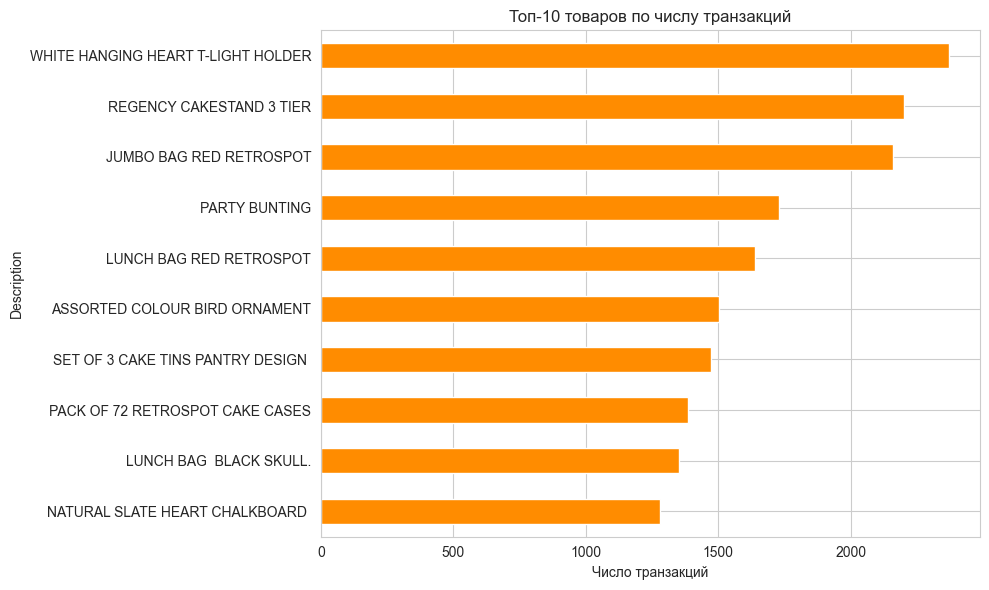

In [11]:
plt.figure(figsize=(10, 6))
df["Description"].value_counts().head(10).plot(kind="barh", color="darkorange")
plt.title("Топ-10 товаров по числу транзакций")
plt.xlabel("Число транзакций")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

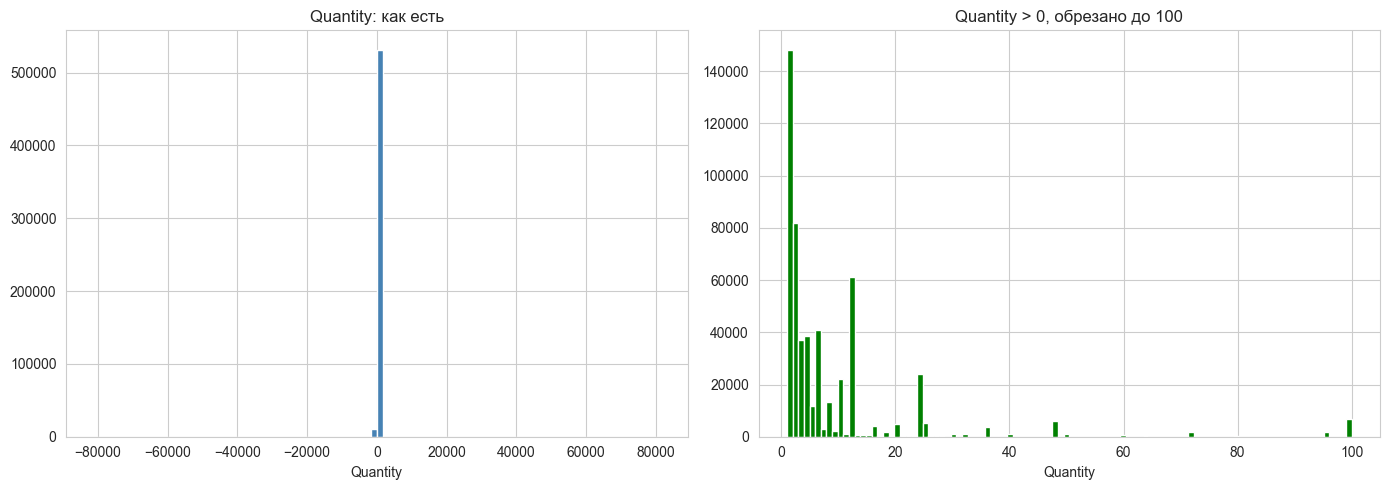

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Quantity"].hist(bins=100, ax=axes[0], color="steelblue")
axes[0].set_title("Quantity: как есть")
axes[0].set_xlabel("Quantity")

q99 = df[df["Quantity"] > 0]["Quantity"].quantile(0.99)
df[df["Quantity"] > 0]["Quantity"].clip(upper=q99).hist(bins=100, ax=axes[1], color="green")
axes[1].set_title(f"Quantity > 0, обрезано до {q99:.0f}")
axes[1].set_xlabel("Quantity")

plt.tight_layout()
plt.show()

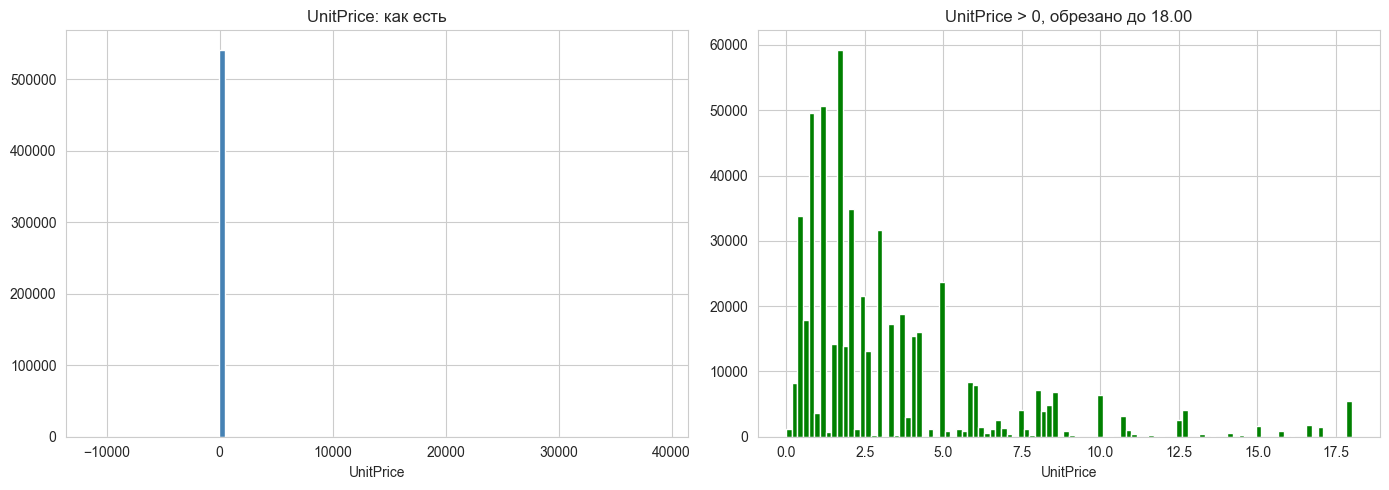

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["UnitPrice"].hist(bins=100, ax=axes[0], color="steelblue")
axes[0].set_title("UnitPrice: как есть")
axes[0].set_xlabel("UnitPrice")

p99 = df[df["UnitPrice"] > 0]["UnitPrice"].quantile(0.99)
df[df["UnitPrice"] > 0]["UnitPrice"].clip(upper=p99).hist(bins=100, ax=axes[1], color="green")
axes[1].set_title(f"UnitPrice > 0, обрезано до {p99:.2f}")
axes[1].set_xlabel("UnitPrice")

plt.tight_layout()
plt.show()

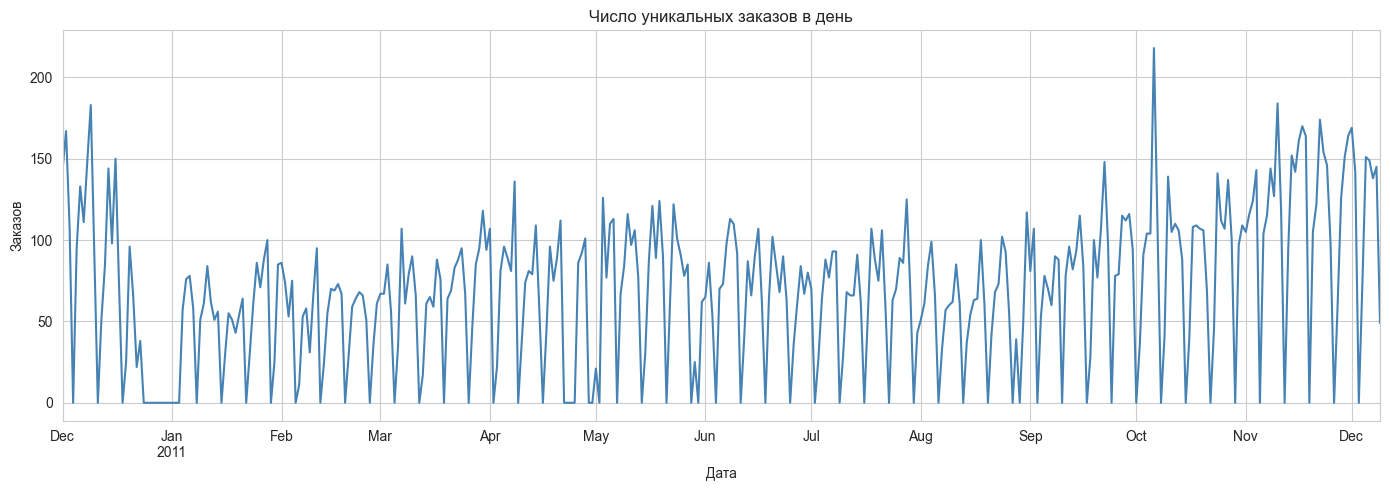

In [17]:
daily = df.set_index("InvoiceDate").resample("D")["InvoiceNo"].nunique()

plt.figure(figsize=(14, 5))
daily.plot(color="steelblue")
plt.title("Число уникальных заказов в день")
plt.ylabel("Заказов")
plt.xlabel("Дата")
plt.tight_layout()
plt.show()

In [14]:
top_customers = (
    df.groupby("CustomerID")["InvoiceNo"].nunique()
    .sort_values(ascending=False).head(10)
)
print(top_customers)

CustomerID
14911.0    248
12748.0    224
17841.0    169
14606.0    128
13089.0    118
15311.0    118
12971.0     89
14527.0     86
13408.0     81
14646.0     77
Name: InvoiceNo, dtype: int64


In [15]:
purchases_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()

print(purchases_per_customer.describe())
print()
print("Клиентов с >= 10 заказами:",
      (purchases_per_customer >= 10).sum())
print("Клиентов с >= 5 заказами:",
      (purchases_per_customer >= 5).sum())

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

Клиентов с >= 10 заказами: 537
Клиентов с >= 5 заказами: 1375


# Итоги EDA

## Что за данные
- 541 909 транзакций за 01.12.2010 – 09.12.2011
- 8 колонок: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
- 4 372 уникальных клиента, ~4 000 уникальных товаров (посчитаем точно после очистки)

## Проблемы
1. 135 080 пропусков в CustomerID (24.93%) — гостевые покупки 
2. 1 454 пропуска в Description 
3. Отмены (InvoiceNo начинается с 'C') — 9 251 
4. Отрицательный Quantity (возвраты) 
5. Отрицательный/нулевой UnitPrice 
6. 5 268 полных дубликатов 
7. InvoiceDate — строка, нужно парсить в datetime

## Наблюдения
- 91% транзакций — United Kingdom
- Явная сезонность: пики перед Рождеством
- Большинство клиентов с 1–3 заказами, но есть VIP-клиенты с длинной историей
- Распределения Quantity и UnitPrice сильно смещены — есть опт

## Стратегия для рекомендательной системы
- Учиться только на клиентах с длинной историей (>= 5 или >= 10 заказов)
- Использовать только успешные покупки: Quantity > 0, UnitPrice > 0, CustomerID not null, InvoiceNo без 'C'
- Словарь товаров ограничить топ-5000 бестселлерами
- Разбить по времени: train / val / test